# CarWorth — Data Cleaning & Feature Engineering
**Input:** `data/raw/vehicles.csv`  
**Output:** `data/processed/vehicles_clean.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load Raw Data

In [2]:
df = pd.read_csv('../data/raw/vehicles.csv')
print(f'Raw shape: {df.shape}')
df.head(3)

Raw shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN


## 2. Drop Irrelevant / High-Missing Columns

In [3]:
# Drop cols with >60% missing or not useful for ML
drop_cols = [
    'id', 'url', 'region_url', 'image_url', 'description',
    'county',   # >99% missing
    'size',     # ~72% missing
    'VIN',      # identifier, not predictive
    'region',   # redundant with state
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
print(f'After dropping cols: {df.shape}')

After dropping cols: (426880, 17)


## 3. Filter Price Outliers

In [4]:
before = len(df)
df = df[(df['price'] >= 500) & (df['price'] <= 150_000)]
print(f'Removed {before - len(df):,} rows with price outside [$500, $150K]. Remaining: {len(df):,}')

Removed 42,290 rows with price outside [$500, $150K]. Remaining: 384,590


## 4. Filter Year Outliers

In [5]:
before = len(df)
df = df[(df['year'] >= 1990) & (df['year'] <= 2024)]
print(f'Removed {before - len(df):,} rows with invalid year. Remaining: {len(df):,}')

Removed 13,005 rows with invalid year. Remaining: 371,585


## 5. Odometer Cleaning

In [6]:
before = len(df)
df = df[(df['odometer'] >= 0) & (df['odometer'] <= 350_000)]
print(f'Removed {before - len(df):,} rows with invalid odometer. Remaining: {len(df):,}')

Removed 3,510 rows with invalid odometer. Remaining: 368,075


## 6. Handle Missing Values

In [7]:
# Categorical: fill with 'unknown'
cat_fill = ['manufacturer', 'model', 'condition', 'cylinders', 'fuel',
            'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']

for col in cat_fill:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')

# Numeric: fill with median
df['odometer'] = df['odometer'].fillna(df['odometer'].median())

print('Missing values after fill:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after fill:
lat     3365
long    3365
dtype: int64


## 7. Feature Engineering

In [8]:
# Car age
df['car_age'] = 2024 - df['year'].astype(int)

# Age-odometer interaction (average miles per year)
df['miles_per_year'] = df['odometer'] / df['car_age'].replace(0, 1)

# Log price (target for modeling)
df['log_price'] = np.log1p(df['price'])

# Log odometer
df['log_odometer'] = np.log1p(df['odometer'])

# Is luxury brand
luxury_brands = {'bmw', 'mercedes-benz', 'audi', 'lexus', 'cadillac', 'lincoln', 'infiniti', 'acura', 'volvo', 'jaguar', 'land rover', 'porsche', 'tesla'}
df['is_luxury'] = df['manufacturer'].str.lower().isin(luxury_brands).astype(int)

# Is clean title
df['is_clean_title'] = (df['title_status'] == 'clean').astype(int)

# Is automatic transmission
df['is_automatic'] = (df['transmission'] == 'automatic').astype(int)

print('New features added: car_age, miles_per_year, log_price, log_odometer, is_luxury, is_clean_title, is_automatic')
df[['car_age', 'miles_per_year', 'log_price', 'is_luxury']].head()

New features added: car_age, miles_per_year, log_price, log_odometer, is_luxury, is_clean_title, is_automatic


,car_age,miles_per_year,log_price,is_luxury
27,10,5792.300000,10.422013,0
28,14,5087.785714,10.025307,0
29,4,4790.000000,10.586357,0
30,7,5874.857143,10.341452,0
31,11,11636.363636,9.615872,0


## 8. Normalize / Clean String Columns

In [9]:
str_cols = ['manufacturer', 'model', 'fuel', 'transmission', 'drive', 'type', 'condition', 'state', 'paint_color']
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].str.lower().str.strip()

# Map condition to numeric ordinal
condition_map = {'salvage': 0, 'fair': 1, 'good': 2, 'excellent': 3, 'like new': 4, 'new': 5, 'unknown': 2}
df['condition_num'] = df['condition'].map(condition_map).fillna(2)

## 9. Keep Relevant Columns for Modeling

In [10]:
MODEL_COLS = [
    'price', 'log_price',
    'year', 'car_age', 'odometer', 'log_odometer', 'miles_per_year',
    'manufacturer', 'fuel', 'transmission', 'drive', 'type',
    'condition', 'condition_num', 'cylinders',
    'state', 'paint_color',
    'is_luxury', 'is_clean_title', 'is_automatic'
]

df_model = df[[c for c in MODEL_COLS if c in df.columns]].copy()
print(f'Final shape for modeling: {df_model.shape}')
df_model.dtypes

Final shape for modeling: (368075, 20)


price               int64
log_price         float64
year              float64
car_age             int32
odometer          float64
log_odometer      float64
miles_per_year    float64
manufacturer       object
fuel               object
transmission       object
drive              object
type               object
condition          object
condition_num       int64
cylinders          object
state              object
paint_color        object
is_luxury           int32
is_clean_title      int32
is_automatic        int32
dtype: object

## 10. Visualize Cleaned Data

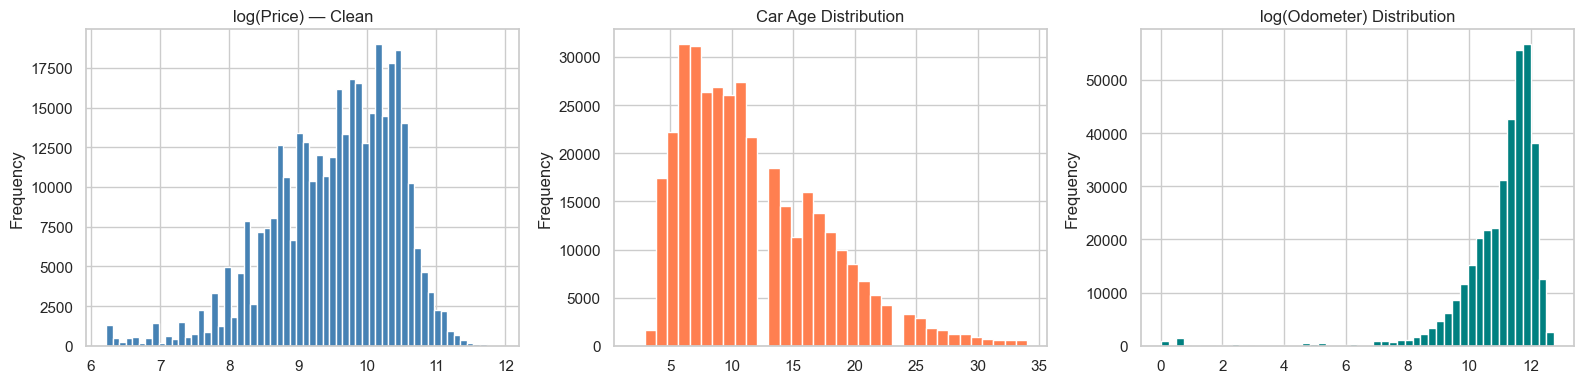

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_model['log_price'].plot(kind='hist', bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('log(Price) — Clean')

df_model['car_age'].plot(kind='hist', bins=35, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Car Age Distribution')

df_model['log_odometer'].plot(kind='hist', bins=50, ax=axes[2], color='teal', edgecolor='white')
axes[2].set_title('log(Odometer) Distribution')

plt.tight_layout()
plt.savefig('../assets/02_cleaning/clean_distributions.png', dpi=150)
plt.show()

## 11. Save Cleaned Dataset

In [12]:
df_model.to_csv('../data/processed/vehicles_clean.csv', index=False)
print(f'Saved to data/processed/vehicles_clean.csv — {df_model.shape[0]:,} rows, {df_model.shape[1]} columns')

Saved to data/processed/vehicles_clean.csv — 368,075 rows, 20 columns
